In [ ]:
import matplotlib.pyplot as plt

In [ ]:
shuntserve_latencies = {
    "mean": 160769.36 / 1000, 
    "p10": 40763.34 / 1000,
    "p25": 67697.27 / 1000,
    "p50": 153075.73 / 1000,
    "p75": 251683.76 / 1000,
    "p90": 280122.95 / 1000,
}

hexgen_latencies = {
    "mean": 294886.32 / 1000,
    "p10": 73703.64 / 1000,
    "p25": 120290.12 / 1000,
    "p50": 273826.27 / 1000,
    "p75": 455315.37 / 1000,
    "p90": 496651.05 / 1000,
}

alpaserve_latencies = {
    "mean": 174928.43 / 1000,
    "p10": 35776.35 / 1000,
    "p25": 72258.02 / 1000,
    "p50": 133862.92 / 1000,
    "p75": 301624.73 / 1000,
    "p90": 346777.50 / 1000,
}

homogeneous_latencies = {
    "mean": 155274.97 / 1000,
    "p10": 31606.92 / 1000,
    "p25": 60281.44 / 1000,
    "p50": 129138.39 / 1000,
    "p75": 253795.26 / 1000,
    "p90": 311608.94 / 1000,
}

In [ ]:
shuntserve_ttfts = {
    "mean": 1952.54 / 1000,
    "p10": 480.29 / 1000,
    "p25": 804.93 / 1000,
    "p50": 1551.74 / 1000,
    "p75": 2085.02 / 1000,
    "p90": 2947.50 / 1000,
}

hexgen_ttfts = {
    "mean": 2097.49 / 1000,
    "p10": 736.07 / 1000,
    "p25": 1139.56 / 1000,
    "p50": 2084.72 / 1000,
    "p75": 2680.73 / 1000,
    "p90": 3539.10 / 1000,
}

alpaserve_ttfts = {
    "mean": 1824.72 / 1000,
    "p10": 482.20 / 1000,
    "p25": 821.82 / 1000,
    "p50": 1605.49 / 1000,
    "p75": 2256.58 / 1000,
    "p90": 2935.34 / 1000,
}

homogeneous_ttfts = {
    "mean": 1699.52 / 1000,
    "p10": 464.98 / 1000,
    "p25": 802.67 / 1000,
    "p50": 1545.61 / 1000,
    "p75": 2179.82 / 1000,
    "p90": 2820.01 / 1000,
}

In [ ]:
shuntserve_tpots = {
    "mean": 587.52 / 1000,
    "p10": 407.42 / 1000,
    "p25": 494.22 / 1000,
    "p50": 596.50 / 1000,
    "p75": 658.97 / 1000,
    "p90": 717.36 / 1000,
}

hexgen_tpots = {
    "mean": 1068.99 / 1000,
    "p10": 779.33 / 1000,
    "p25": 1011.11 / 1000,
    "p50": 1114.86 / 1000,
    "p75": 1172.65 / 1000,
    "p90": 1246.41 / 1000,
}

alpaserve_tpots = {
    "mean": 636.31 / 1000,
    "p10": 277.96 / 1000,
    "p25": 394.02 / 1000,
    "p50": 727.95 / 1000,
    "p75": 811.25 / 1000,
    "p90": 907.13 / 1000,
}

homogeneous_tpots = {
    "mean": 558.75 / 1000,
    "p10": 296.05 / 1000,
    "p25": 389.37 / 1000,
    "p50": 587.24 / 1000,
    "p75": 727.56 / 1000,
    "p90": 810.43 / 1000,
}

In [ ]:
import matplotlib.patches as mpatches
import matplotlib as mpl
import numpy as np

# Set hatch linewidth to make patterns more visible
mpl.rcParams['hatch.linewidth'] = 2.0

# Font size control
FONTSIZE = 50

# Colors and hatches from measure_estimate_throughput_o.ipynb
colors = ['#3498db', '#1abc9c', '#e91e63', '#9b59b6']  # ShuntServe, Hexgen, AlpaServe, Homogeneous
hatches = ['/', '\\', 'x', '+']

def plot_single_metric(data_dict, ylabel, filename, ytick_interval=None, title_fontsize=35, label_fontsize=35, tick_fontsize=35):
    """
    Plot box plot for a single metric.
    
    Parameters:
    -----------
    data_dict : dict
        Dictionary containing data for each system (shuntserve, hexgen, alpaserve, homogeneous)
    ylabel : str
        Y-axis label
    filename : str
        Output filename
    ytick_interval : float, optional
        Interval for y-axis ticks (e.g., 0.5 for 0.5 spacing)
    title_fontsize : int
        Font size for title
    label_fontsize : int
        Font size for axis labels
    tick_fontsize : int
        Font size for tick labels
    """
    
    fig, ax = plt.subplots(figsize=(10, 11))
    
    systems = ['ShuntServe', 'Hexgen', 'AlpaServe', 'Homogeneous']
    positions = [1, 2, 3, 4]
    
    for i, (system, pos) in enumerate(zip(systems, positions)):
        system_key = system.lower().replace('serve', 'serve')
        if system == 'ShuntServe':
            data = data_dict['shuntserve']
        elif system == 'Hexgen':
            data = data_dict['hexgen']
        elif system == 'AlpaServe':
            data = data_dict['alpaserve']
        else:  # Homogeneous
            data = data_dict['homogeneous']
        
        # Extract percentiles
        p10 = data['p10']
        p25 = data['p25']
        p50 = data['p50']
        p75 = data['p75']
        p90 = data['p90']
        
        # Draw box (p25 to p75)
        box_height = p75 - p25
        box = plt.Rectangle((pos - 0.3, p25), 0.6, box_height, 
                           facecolor=colors[i], alpha=0.8, edgecolor='black', 
                           linewidth=0.5, hatch=hatches[i])
        ax.add_patch(box)
        
        # Draw median line (p50) in red
        ax.plot([pos - 0.3, pos + 0.3], [p50, p50], color='orange', linewidth=10, alpha=1)
        
        # Draw whiskers
        # Lower whisker (p10 to p25)
        ax.plot([pos, pos], [p10, p25], 'k-', linewidth=1.5)
        ax.plot([pos - 0.15, pos + 0.15], [p10, p10], 'k-', linewidth=1.5)
        
        # Upper whisker (p75 to p90)
        ax.plot([pos, pos], [p75, p90], 'k-', linewidth=1.5)
        ax.plot([pos - 0.15, pos + 0.15], [p90, p90], 'k-', linewidth=1.5)
    
    ax.set_xticks(positions)
    # Remove x-axis labels
    ax.set_xticklabels([])
    ax.set_ylabel(ylabel, fontsize=label_fontsize)
    ax.tick_params(axis='y', labelsize=tick_fontsize)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_xlim(0.5, 4.5)
    ax.set_axisbelow(True)
    
    # Set y-axis ticks if interval is specified
    if ytick_interval is not None:
        ymin, ymax = ax.get_ylim()
        yticks = np.arange(0, ymax * 1.1, ytick_interval)
        ax.set_yticks(yticks)
    
    plt.tight_layout()
    plt.savefig(filename, format='pdf', bbox_inches='tight')
    plt.show()
    
    return fig

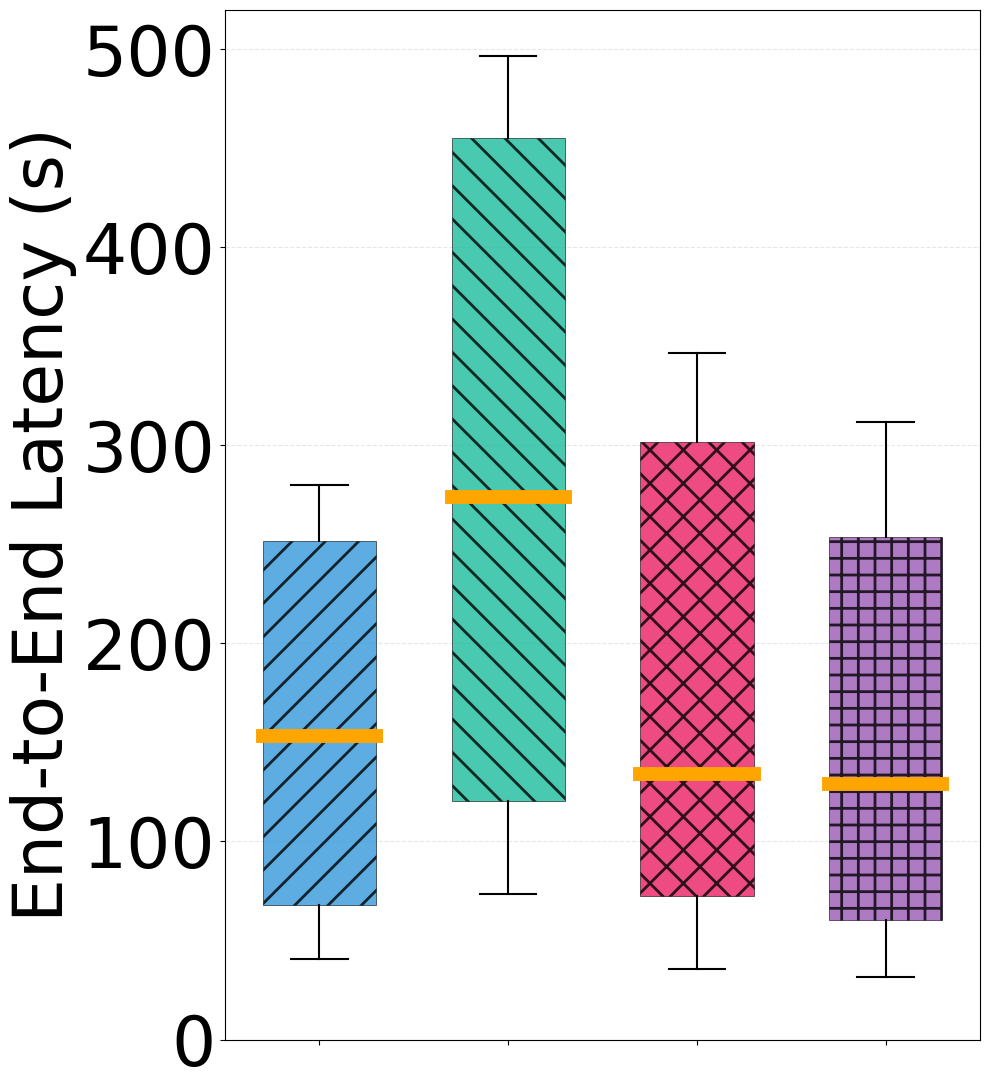

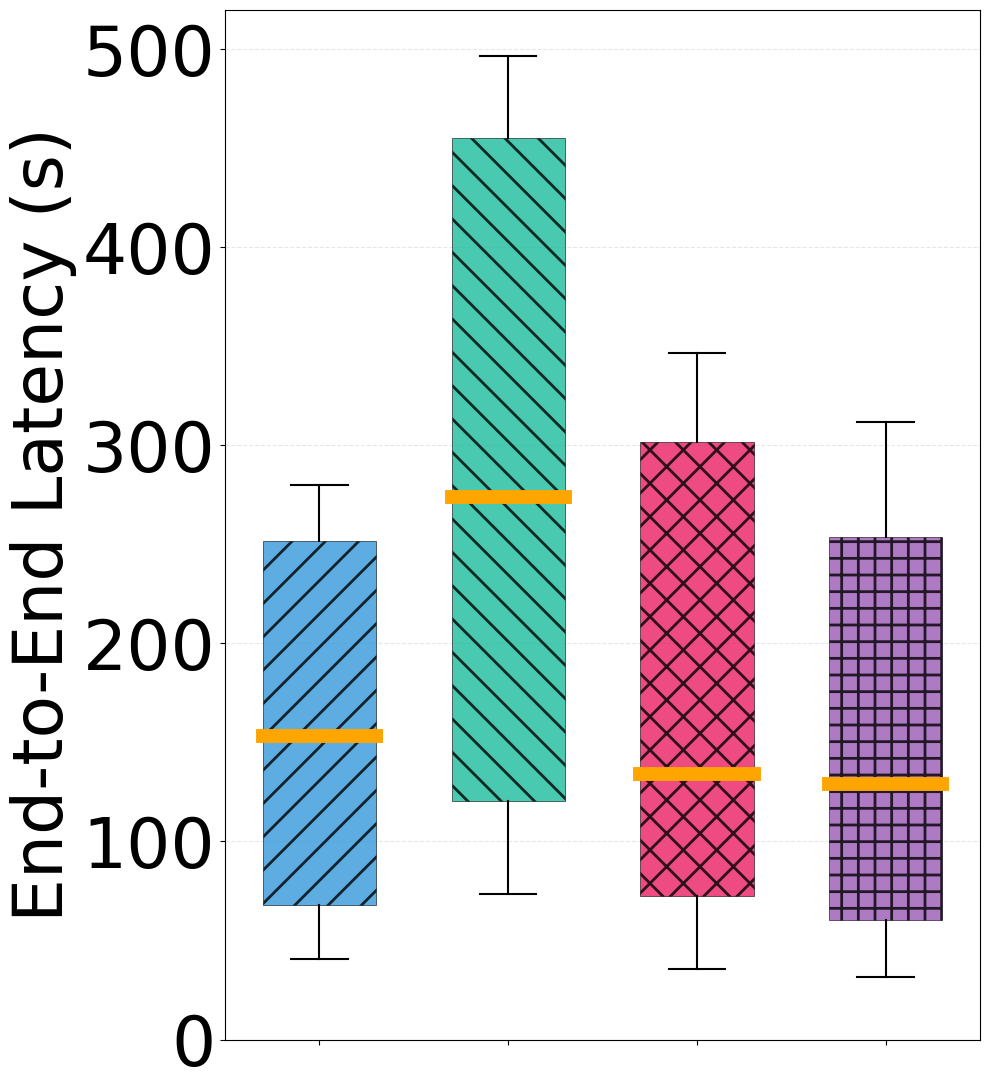

In [ ]:
# Organize data by system
latencies_by_system = {
    'shuntserve': shuntserve_latencies,
    'hexgen': hexgen_latencies,
    'alpaserve': alpaserve_latencies,
    'homogeneous': homogeneous_latencies
}

ttfts_by_system = {
    'shuntserve': shuntserve_ttfts,
    'hexgen': hexgen_ttfts,
    'alpaserve': alpaserve_ttfts,
    'homogeneous': homogeneous_ttfts
}

tpots_by_system = {
    'shuntserve': shuntserve_tpots,
    'hexgen': hexgen_tpots,
    'alpaserve': alpaserve_tpots,
    'homogeneous': homogeneous_tpots
}

# Plot End-to-End Latency
plot_single_metric(latencies_by_system, 'End-to-End Latency (s)', 'model_placement_latency_endtoend.pdf', ytick_interval=100, tick_fontsize=FONTSIZE, label_fontsize=FONTSIZE)

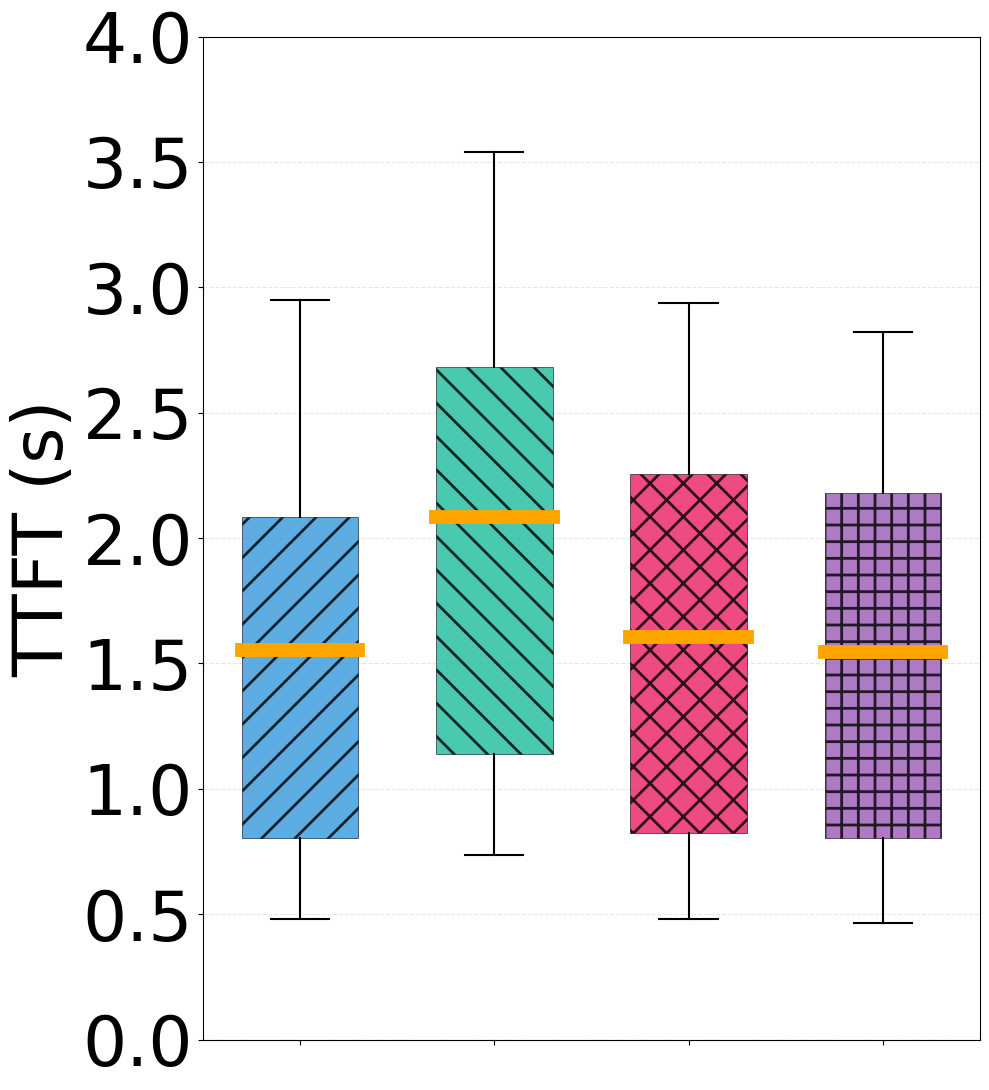

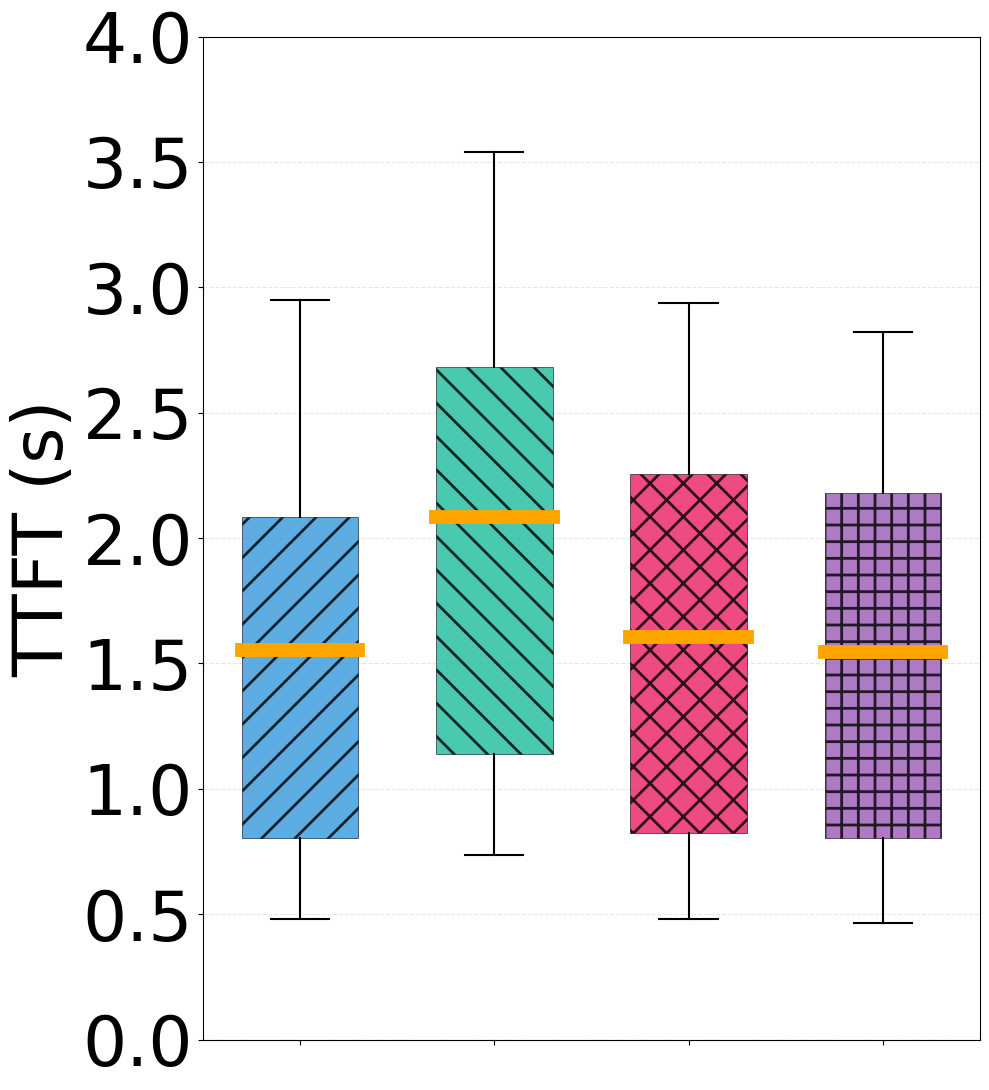

In [ ]:
# Plot TTFT with 0.5 interval y-ticks
plot_single_metric(ttfts_by_system, 'TTFT (s)', 'model_placement_latency_ttft.pdf', ytick_interval=0.5, tick_fontsize=FONTSIZE, label_fontsize=FONTSIZE)

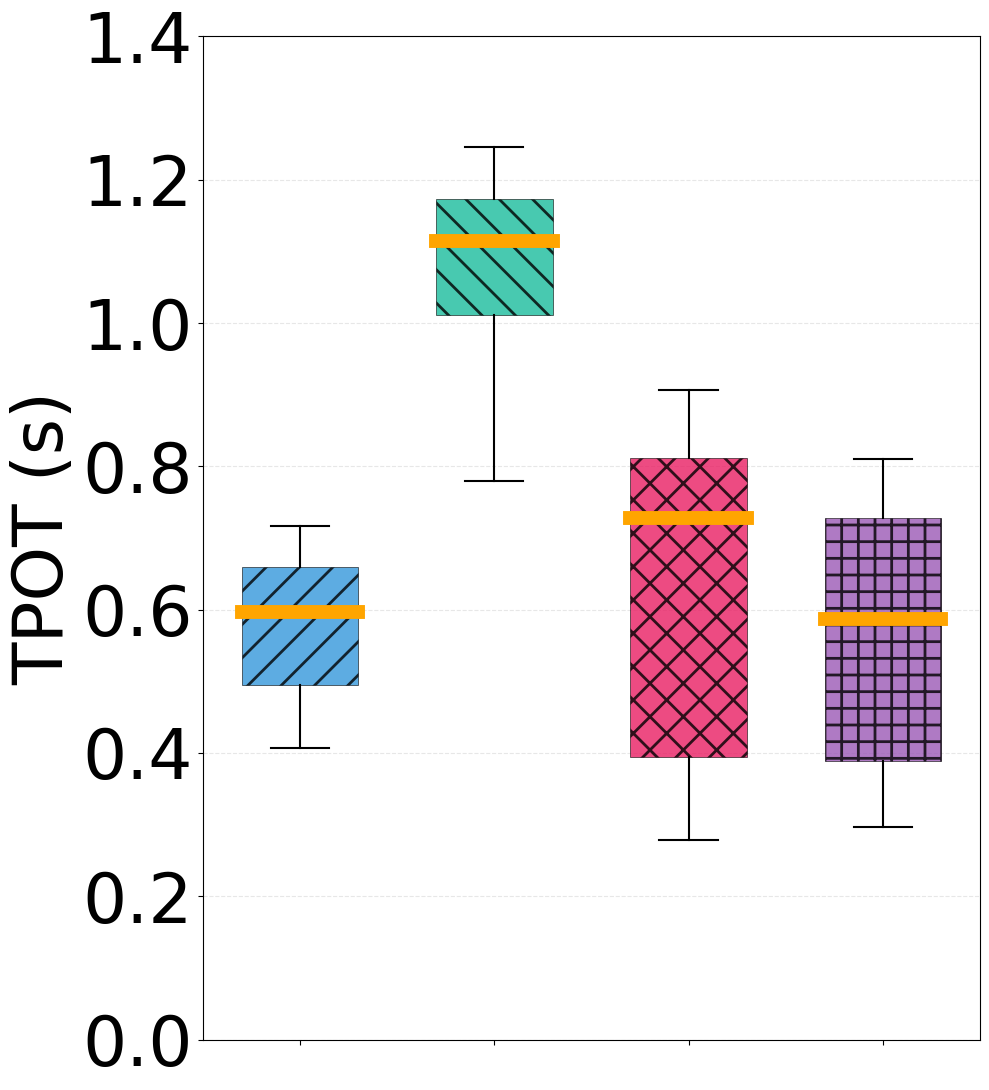

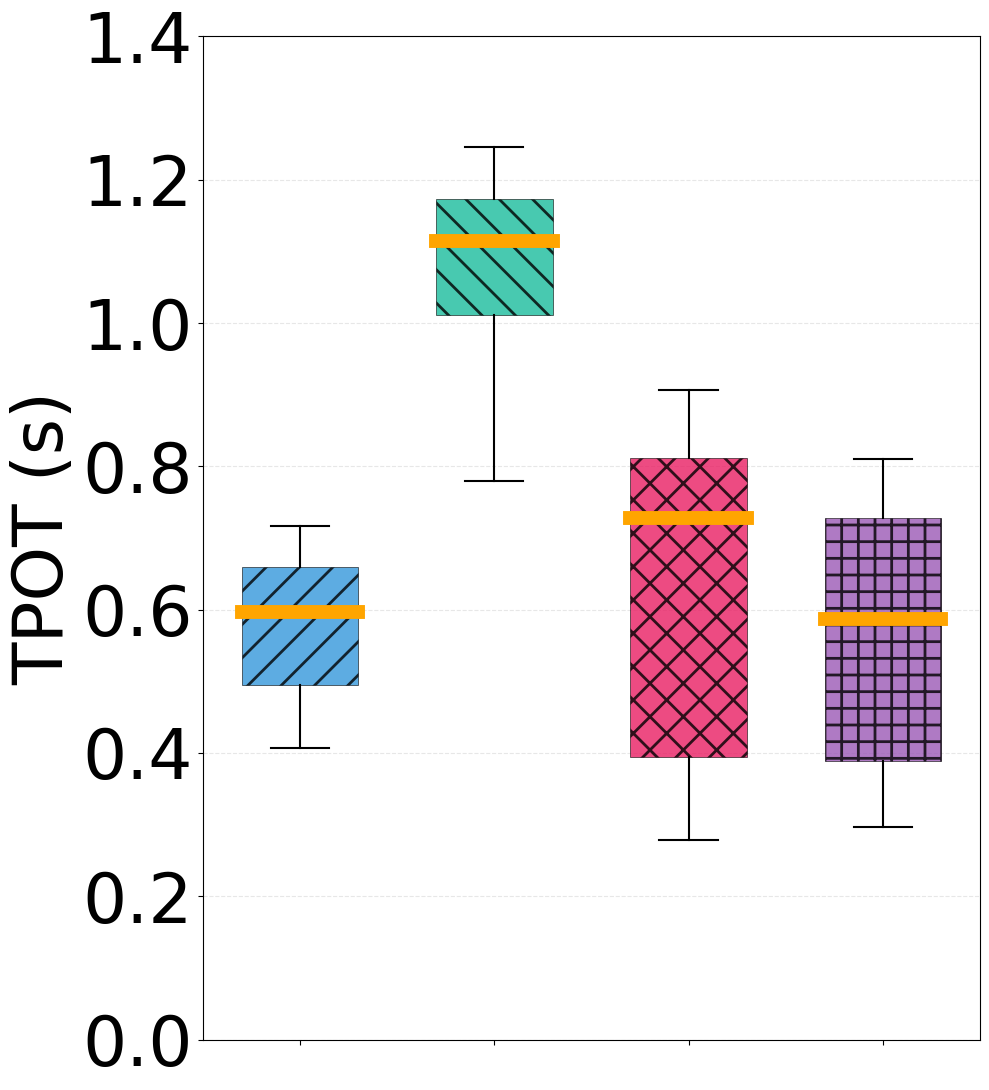

In [ ]:
# Plot TPOT
plot_single_metric(tpots_by_system, 'TPOT (s)', 'model_placement_latency_tpot.pdf', ytick_interval=0.2, tick_fontsize=FONTSIZE, label_fontsize=FONTSIZE)

/var/folders/zh/42llgg8s6gz6rjh2s2z_x7900000gn/T/ipykernel_30625/3423955734.py:16: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


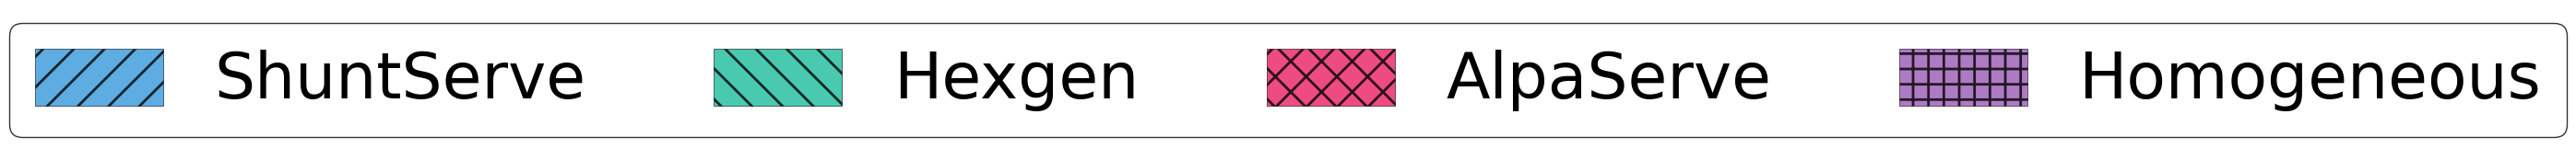

In [ ]:
# Create legend only
fig, ax = plt.subplots(figsize=(10, 2))
ax.axis('off')

systems = ['ShuntServe', 'Hexgen', 'AlpaServe', 'vLLM']

# Create legend patches with hatch patterns
legend_patches = [mpatches.Patch(facecolor=colors[i], label=systems[i], alpha=0.8, 
                                 edgecolor='black', linewidth=0.5, hatch=hatches[i]) 
                  for i in range(len(systems))]

# Add legend
ax.legend(handles=legend_patches, loc='center', ncol=4, fontsize=FONTSIZE, 
          frameon=True, handlelength=2, handleheight=1, edgecolor='black')

plt.tight_layout()
plt.savefig('model_placement_latency_legend.pdf', format='pdf', bbox_inches='tight')
plt.show()